In [32]:
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── 参数 ────────────────────────────────────────────────
STEP = 3          # which denoising step
BLOCK = 7         # which block（0~7 = double-stream, 8~24 = single-stream）
HEATMAP_DIR = "./maps"

maps = torch.load(f"{HEATMAP_DIR}/step_{STEP:03d}.pt")
# shape: (num_blocks, Seq_img, Seq_img)
print(f"maps.shape = {maps.shape}")

Seq_img = maps.shape[1]
import math
H_GRID = W_GRID = int(math.isqrt(Seq_img))
print(f"H_GRID = W_GRID = {H_GRID}  (Seq_img={Seq_img})")

attn = maps[BLOCK]   # (Seq_img, Seq_img)

maps.shape = torch.Size([25, 4096, 4096])
H_GRID = W_GRID = 64  (Seq_img=4096)


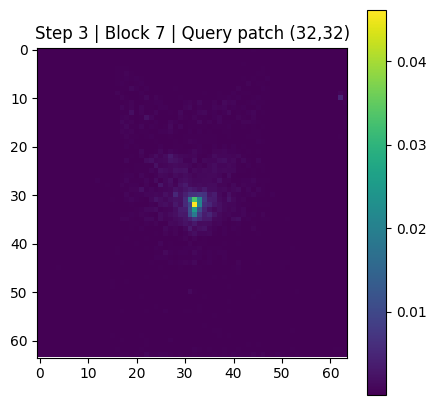

In [33]:
# Choose query patch (i.e., center)
query_row, query_col = H_GRID // 2, W_GRID // 2
query_idx = query_row * W_GRID + query_col

attn_map = attn[query_idx].reshape(H_GRID, W_GRID).numpy()

plt.figure(figsize=(5, 5))
plt.imshow(attn_map, cmap="viridis")
plt.colorbar()
plt.title(f"Step {STEP} | Block {BLOCK} | Query patch ({query_row},{query_col})")
plt.show()
